> 📅 Learning Progress: Day 16 of my Machine Learning journey
> In this project, I will use the dataset "Advertising Simple Dataset" from Jacky Huang on Kaggle.
> Jacky Huang as known as Jia Huang. He is the Lead Research Engineer at A*STAR | Author of Designing AI Agents | Applied GenAI, RAG, AI Agents, and Enterprise AI Systems
> I am learning machine learning based on the books he published.
>Linkedin: https://www.linkedin.com/in/jia-huang-74657145/



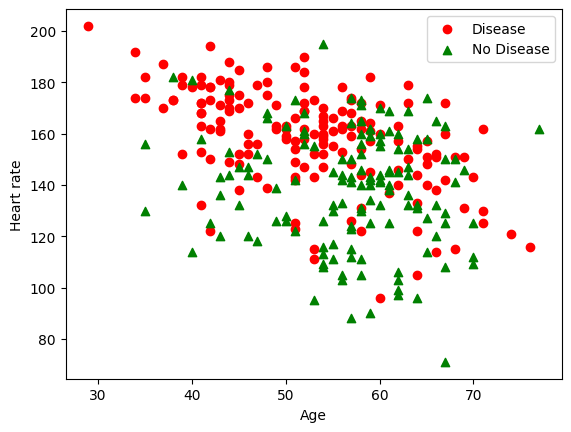

In [144]:
#In this file, there are three scenarios:
#1.target=1 indicates heart disease.
#2.target=0 indicates no heart disease.
#3.If the “target” column is blank, the data is unlabeled.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df_heart = pd.read_csv("heart.csv")
df_heart.head()

df_heart.target.value_counts()

#Using age and maximum heart rate as inputs, view the scatter plot of the classification results
plt.scatter(x=df_heart.age[df_heart.target==1],y=df_heart.thalach[df_heart.target==1],c="red",label="Disease")
plt.scatter(x=df_heart.age[df_heart.target==0],y=df_heart.thalach[df_heart.target==0],marker='^',c="green",label="No Disease")
plt.legend()
plt.xlabel("Age")
plt.ylabel("Heart rate")
plt.show()




In [145]:
#We get the graph of Disease and No Disease above, now we start to build feature sets.
x=df_heart.drop(['target'],axis=1)
y=df_heart.target.values
y=y.reshape(len(y),1)
print("shape of x:",x.shape)
print("shape of y:",y.shape)

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

# Normalization
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train) # fit_transform is fitting first then apply it.
x_test = scaler.transform(x_test) # transform apply it directly.


shape of x: (303, 13)
shape of y: (303, 1)


In [146]:
# Start to define functions.
def sigmoid(z):
    y_hat = 1/(1+np.exp(-z))
    return y_hat

def loss_function(x,y,w,b):
    y_hat = sigmoid(np.dot(x,w)+b)
    loss = -((y*np.log(y_hat)+(1-y)*np.log(1-y_hat)))
    cost = np.sum(loss)/x.shape[0]
    return cost

def gradient_descent(x,y,w,b,lr,iter):# lr is learning rate
    l_history = np.zeros(iter)
    w_history = np.zeros((iter,w.shape[0],w.shape[1])) # This is different from Project 4. This is 3D tensor.
    b_history = np.zeros(iter)
    for i in range(iter):
        y_hat = sigmoid(np.dot(x,w)+b)
        loss = -(y*np.log(y_hat)+(1-y)*np.log(1-y_hat))
        derivative_w = np.dot(x.T,(y_hat-y)/x.shape[0])
        derivative_b = np.sum(y_hat-y)/x.shape[0]
        w = w-lr*derivative_w
        b = b-lr*derivative_b
        l_history[i]=loss_function(x,y,w,b)
        print("iter number:",i+1,"the current loss of train datasets:",l_history[i])
        w_history[i]=w
        b_history[i]=b
    return l_history,w_history,b_history

def predict(x,w,b):
    z = np.dot(x,w)+b
    y_hat = sigmoid(z)
    y_pred = np.zeros((y_hat.shape[0],1))
    for i in range(y_hat.shape[0]):
        if y_hat[i,0]<0.5:
            y_pred[i,0]=0
        else:
            y_pred[i,0]=1
    return y_pred

def logistic_regression(x,y,w,b,lr,iter):
    l_history,w_history,b_history=gradient_descent(x,y,w,b,lr,iter)
    print("Final train loss:",l_history[-1])
    y_pred = predict(x,w_history[-1],b_history[-1])
    training_acc = 100-np.mean(np.abs(y_pred-y_train))*100
    print("Accurary:{:.2f}%".format(training_acc))
    return l_history,w_history,b_history


In [147]:
#Initialize
dimension = x.shape[1]
weight = np.full((dimension,1),0.1)# weight vector, usually 1D,but here is 2D tensor.
bias = 0
alpha = 1
iterations = 500


loss_history,weight_history,bias_history = logistic_regression(x_train,y_train,weight,bias,alpha,iterations)


iter number: 1 the current loss of train datasets: 0.6729089268087904
iter number: 2 the current loss of train datasets: 0.6491751054908034
iter number: 3 the current loss of train datasets: 0.6285498303771099
iter number: 4 the current loss of train datasets: 0.6104483211243416
iter number: 5 the current loss of train datasets: 0.5945080119507831
iter number: 6 the current loss of train datasets: 0.5804179443879518
iter number: 7 the current loss of train datasets: 0.5679130512672029
iter number: 8 the current loss of train datasets: 0.5567685516917082
iter number: 9 the current loss of train datasets: 0.5467943786284363
iter number: 10 the current loss of train datasets: 0.5378300004589225
iter number: 11 the current loss of train datasets: 0.5297398057464111
iter number: 12 the current loss of train datasets: 0.5224090995316044
iter number: 13 the current loss of train datasets: 0.5157406915546
iter number: 14 the current loss of train datasets: 0.5096520230374826
iter number: 15 th

logistic regression accuracy:91.80%


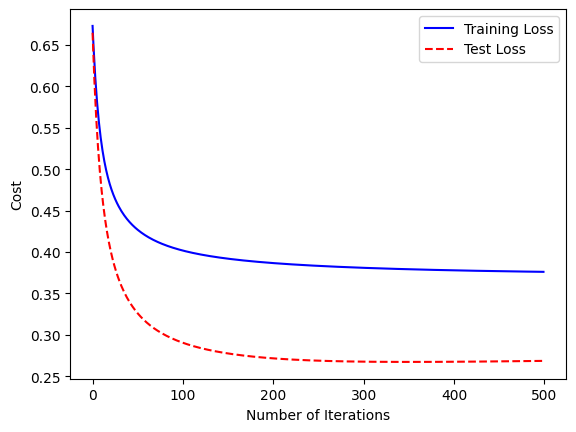

In [148]:
y_pred = predict(x_test,weight_history[-1],bias_history[-1])
testing_acc = 100-np.mean(np.abs(y_pred - y_test))*100
print("logistic regression accuracy:{:.2f}%".format(testing_acc))

loss_history_test = np.zeros(iterations)
for i in range(iterations):
    loss_history_test[i] = loss_function(x_test,y_test,weight_history[i],bias_history[i])
index = np.arange(0,iterations,1)
plt.plot(index,loss_history,c = 'blue',linestyle = 'solid')
plt.plot(index,loss_history_test,c = 'red',linestyle = 'dashed')
plt.legend(["Training Loss","Test Loss"])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.show()

In [149]:
# We can also use a easy way to do the same thing above done.
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
print("Sk Learn logistic regression accuracy:{:.2f}%".format(lr.score(x_test,y_test)*100))

Sk Learn logistic regression accuracy:91.80%


/Users/lihaolan/.local/share/virtualenvs/TFODCourse-nSCjVZ3l/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
